### 🧹 Data Cleaning Choices
* **Age:** Used `fillna()` with the median (~28) instead of the mean so extreme older ages wouldn't drag the number up.
* **Embarked:** Used `fillna()` with the mode ('S') because over 70% of passengers boarded there.
* **Cabin:** Used `drop()` to delete the column completely because 77% of the data was missing—trying to guess that much missing data is useless.

In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('titanic.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'])

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\ahmed\AppData\Local\Temp\ipykernel_23804\1447650758.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1,0], palette='pastel')


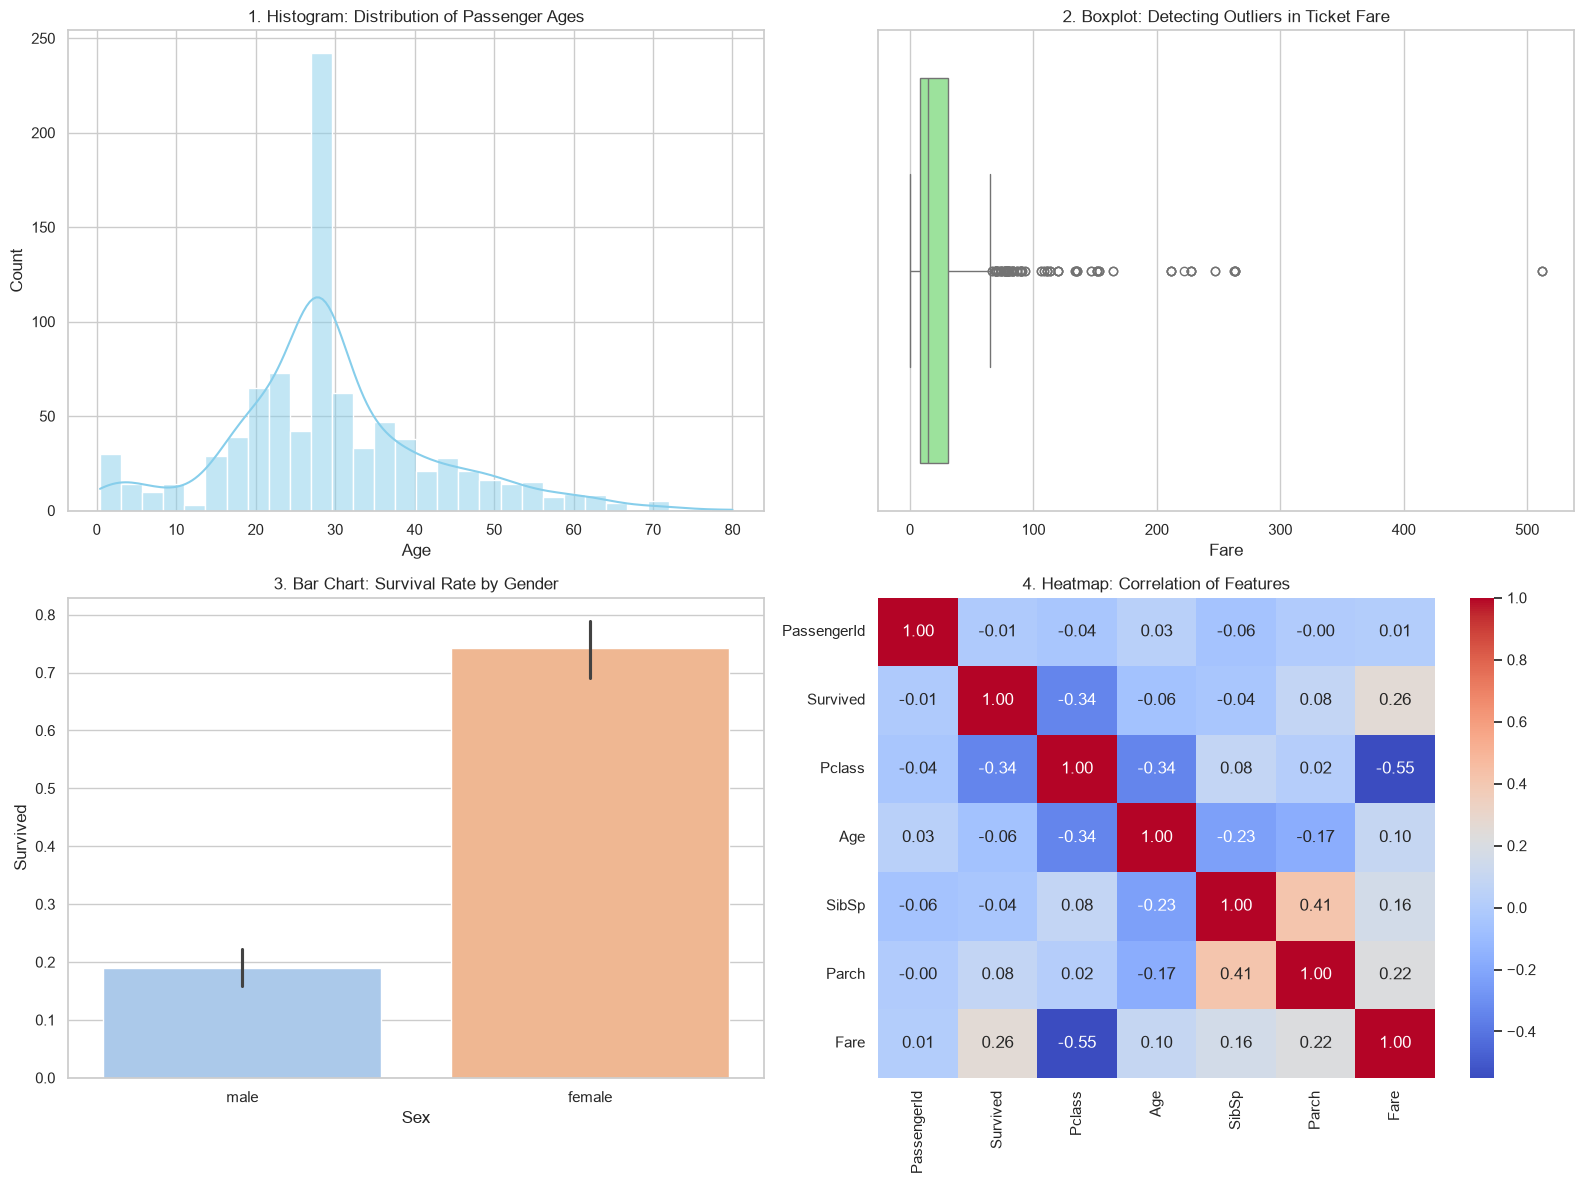

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('1. Histogram: Distribution of Passenger Ages')

sns.boxplot(x=df['Fare'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('2. Boxplot: Detecting Outliers in Ticket Fare')

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1,0], palette='pastel')
axes[1,0].set_title('3. Bar Chart: Survival Rate by Gender')

numeric_cols = df.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,1])
axes[1,1].set_title('4. Heatmap: Correlation of Features')

plt.tight_layout()
plt.show()

### 💡 Survival Analysis Conclusion
Based on the visualizations, **Gender (`Sex`)** and **Passenger Class (`Pclass`)** most strongly affect a passenger's chances of survival. The bar chart shows a massive survival advantage for females, and the heatmap shows a strong negative correlation (-0.34) between `Pclass` and `Survived`, proving 1st-class passengers had much better odds than 3rd-class passengers.